In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
historical = pd.read_csv("historical_data.csv")
fear = pd.read_csv("fear_greed_index.csv")

In [3]:
historical.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [4]:
fear.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [5]:
historical.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [6]:
fear.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [7]:
historical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [8]:
fear.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [42]:
historical.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
Date                0
dtype: int64

In [10]:
fear.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [11]:
historical.duplicated().sum()

np.int64(0)

In [12]:
fear.duplicated().sum()

np.int64(0)

In [13]:
historical = historical.drop_duplicates()
fear = fear.drop_duplicates()

In [14]:
historical["Date"] = pd.to_datetime(
    historical["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
).dt.date

In [15]:
fear["Date"] = pd.to_datetime(
    fear["date"]
).dt.date

In [16]:
historical[["Timestamp IST", "Date"]].head()

,Timestamp IST,Date
0,02-12-2024 22:50,2024-12-02
1,02-12-2024 22:50,2024-12-02
2,02-12-2024 22:50,2024-12-02
3,02-12-2024 22:50,2024-12-02
4,02-12-2024 22:50,2024-12-02


In [17]:
fear[["date", "Date"]].head()

,date,Date
0,2018-02-01,2018-02-01
1,2018-02-02,2018-02-02
2,2018-02-03,2018-02-03
3,2018-02-04,2018-02-04
4,2018-02-05,2018-02-05


In [18]:
merged = pd.merge(
    historical,
    fear[["Date", "classification"]],
    on="Date",
    how="left"
)

In [19]:
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


In [20]:
merged.shape

(211224, 18)

In [21]:
merged["classification"].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

In [22]:
print("Total Trades:", len(merged))
print("\nColumns:")
print(merged.columns)

Total Trades: 211224

Columns:
Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp', 'Date', 'classification'],
      dtype='object')


In [23]:
merged.groupby("classification")["Closed PnL"].mean().sort_values(ascending=False)

classification
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Extreme Fear     34.537862
Neutral          34.307718
Name: Closed PnL, dtype: float64

In [24]:
merged.groupby("classification")["Closed PnL"].sum().sort_values(ascending=False)

classification
Fear             3.357155e+06
Extreme Greed    2.715171e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Extreme Fear     7.391102e+05
Name: Closed PnL, dtype: float64

In [25]:
merged["classification"].value_counts()

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

In [26]:
merged["Win"] = merged["Closed PnL"] > 0

merged.groupby("classification")["Win"].mean() * 100

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Win, dtype: float64

In [27]:
merged.groupby("classification")["Fee"].mean()

classification
Extreme Fear     1.116291
Extreme Greed    0.675902
Fear             1.495172
Greed            1.254372
Neutral          1.044798
Name: Fee, dtype: float64

In [28]:
pd.crosstab(
    merged["classification"],
    merged["Direction"]
)

Direction,Auto-Deleveraging,Buy,Close Long,Close Short,Liquidated Isolated Short,Long > Short,Open Long,Open Short,Sell,Settlement,Short > Long,Spot Dust Conversion
classification,,,,,,,,,,,,
Extreme Fear,0,807,6241,3117,0,5,7005,3174,1042,0,6,3
Extreme Greed,0,5132,7186,6497,0,7,6300,7663,7164,0,11,32
Fear,0,3207,17260,9221,0,14,17824,10887,3364,0,18,42
Greed,8,4685,7998,11322,1,16,8544,11664,5986,1,23,55
Neutral,0,2885,9993,5850,0,15,10222,6353,2346,0,12,10


# Exploratory Data Analysis (EDA)

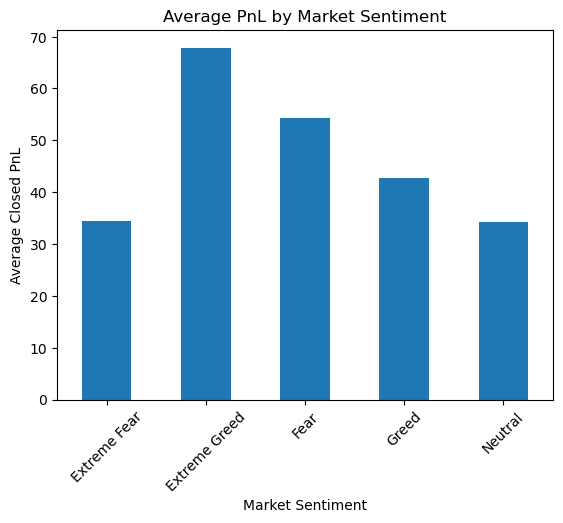

In [29]:
merged.groupby("classification")["Closed PnL"].mean().plot(kind="bar")

plt.title("Average PnL by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.xticks(rotation=45)

plt.show()

## 1. Average Closed PnL by Market Sentiment

### Insight

The average closed PnL varies across different market sentiments. 
Extreme Greed shows the highest average profit, while Neutral and Extreme Fear have relatively lower values. 
This suggests that traders tend to perform better during highly optimistic market conditions.

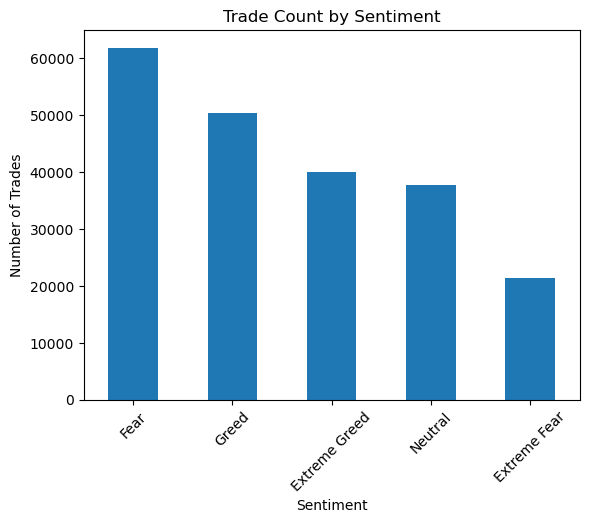

In [30]:
merged["classification"].value_counts().plot(kind="bar")

plt.title("Trade Count by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Trades")
plt.xticks(rotation=45)

plt.show()

## 2. Trade Count by Market Sentiment

### Insight

The number of trades is highest during Fear and Greed market conditions. Extreme Fear has the lowest trade count. This indicates that trading activity is more frequent when the market is moderately fearful or greedy.

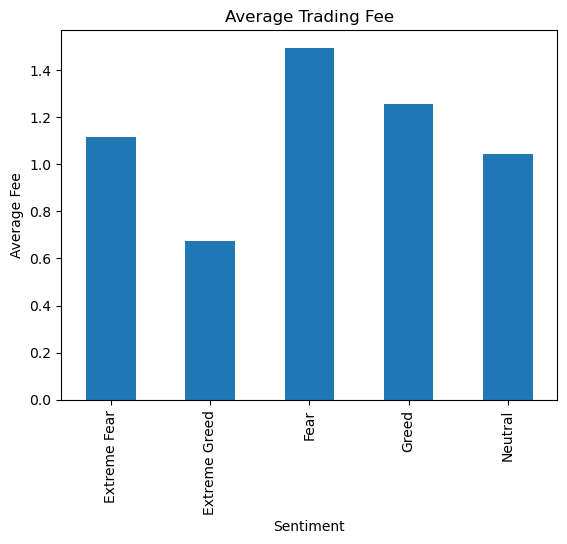

In [31]:
merged.groupby("classification")["Fee"].mean().plot(kind="bar")

plt.title("Average Trading Fee")
plt.xlabel("Sentiment")
plt.ylabel("Average Fee")

plt.show()

## 3. Average Trading Fee by Market Sentiment

### Insight

Average trading fees differ across sentiment categories. Fear has the highest average fee, whereas Extreme Greed has the lowest. This may indicate that larger or more frequent trades were executed during fearful market conditions.

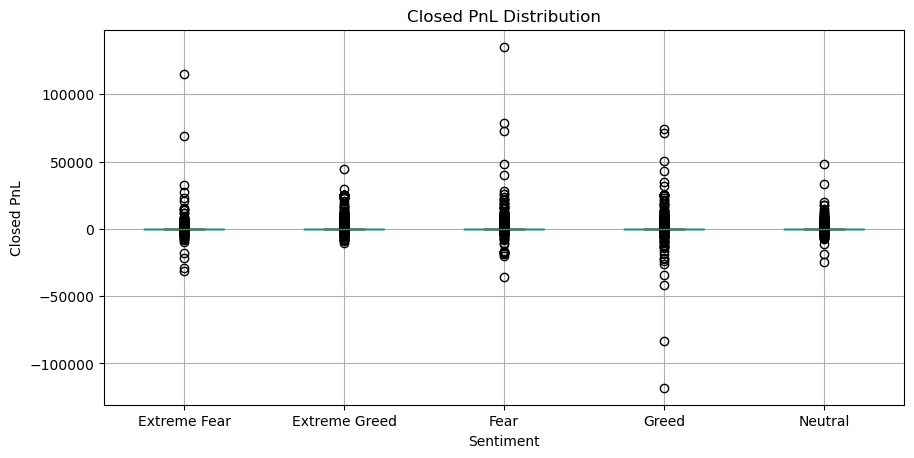

In [32]:
merged.boxplot(column="Closed PnL", by="classification", figsize=(10,5))

plt.title("Closed PnL Distribution")
plt.suptitle("")
plt.xlabel("Sentiment")
plt.ylabel("Closed PnL")

plt.show()

## 4. Closed PnL Distribution by Market Sentiment

### Insight

The boxplot shows that the distribution of profits and losses varies across sentiments. Most trades are concentrated around small profits or losses, while some extreme outliers represent very large gains or losses. Greed and Fear sentiments exhibit higher variability in performance.

In [33]:
merged.groupby("Coin")["Closed PnL"].sum().sort_values(ascending=False).head(10)

Coin
@107       2.783913e+06
HYPE       1.948485e+06
SOL        1.639556e+06
ETH        1.319979e+06
BTC        8.680447e+05
MELANIA    3.903511e+05
ENA        2.173295e+05
SUI        1.992688e+05
ZRO        1.837778e+05
DOGE       1.475432e+05
Name: Closed PnL, dtype: float64

In [34]:
pd.crosstab(merged["classification"], merged["Side"])

Side,BUY,SELL
classification,,
Extreme Fear,10935,10465
Extreme Greed,17940,22052
Fear,30270,31567
Greed,24576,25727
Neutral,18969,18717


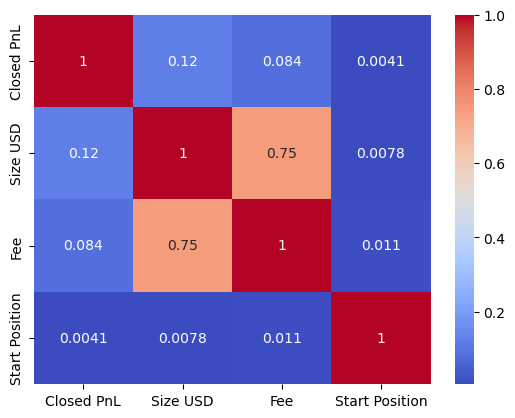

In [35]:
import seaborn as sns

sns.heatmap(
merged[["Closed PnL","Size USD","Fee","Start Position"]].corr(),
annot=True,
cmap="coolwarm")
plt.show()

## 5. Correlation Between Numerical Features

### Insight

The heatmap shows the correlation between Closed PnL, Size USD, Fee, and Start Position.

A strong positive correlation (0.75) is observed between Size USD and Fee, indicating that larger trades generally incur higher fees. However, Closed PnL has very weak correlations with the other variables, suggesting that profitability is not strongly influenced by trade size, fees, or starting position alone. This indicates that other factors, such as market conditions and trading strategy, may have a greater impact on trading performance.

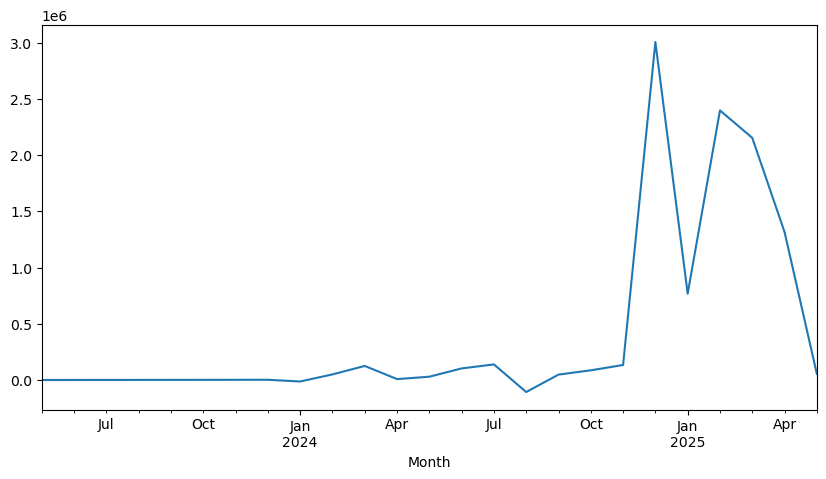

In [36]:
merged["Month"] = pd.to_datetime(merged["Date"]).dt.to_period("M")

merged.groupby("Month")["Closed PnL"].sum().plot(figsize=(10,5))
plt.show()

## 6. Monthly Closed PnL Trend

### Insight

The line chart shows how total Closed PnL changed over time. Profits remained relatively low and stable during the early months, followed by a sharp increase towards the end of 2024. The highest profit was observed around late 2024, after which profitability fluctuated but remained comparatively high. This indicates that trading performance improved significantly during certain periods, possibly due to favorable market conditions.

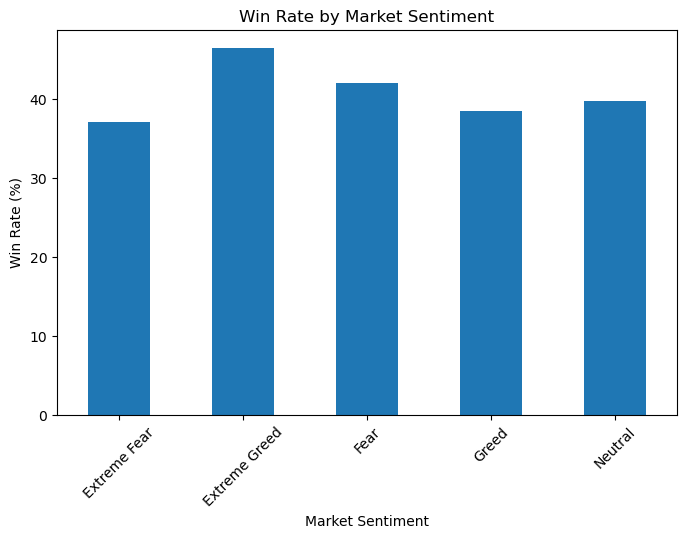

In [37]:
win_rate = merged.groupby("classification")["Win"].mean()*100

win_rate.plot(kind="bar", figsize=(8,5))

plt.title("Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (%)")
plt.xticks(rotation=45)
plt.show()

## 7. Win Rate by Market Sentiment

### Insight

The win rate differs across market sentiments. Extreme Greed achieves the highest win rate, while Extreme Fear has the lowest. This suggests that trades executed during bullish market conditions tend to have a higher probability of success.

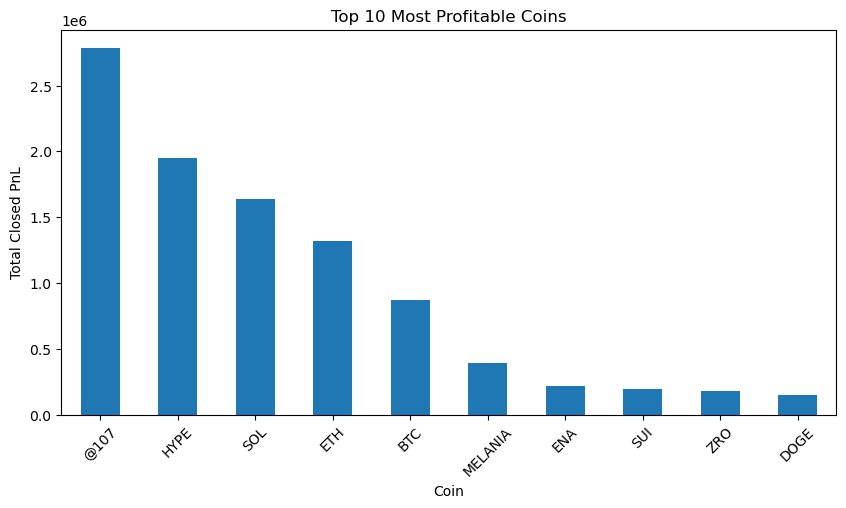

In [38]:
top10 = merged.groupby("Coin")["Closed PnL"].sum().sort_values(ascending=False).head(10)

top10.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Most Profitable Coins")
plt.xlabel("Coin")
plt.ylabel("Total Closed PnL")
plt.xticks(rotation=45)
plt.show()

## 8. Top 10 Most Profitable Coins

### Insight

The chart highlights the coins that generated the highest total profit. @107, HYPE, and SOL contributed the most to overall profitability. This indicates that a significant portion of profits came from a few highly performing assets.

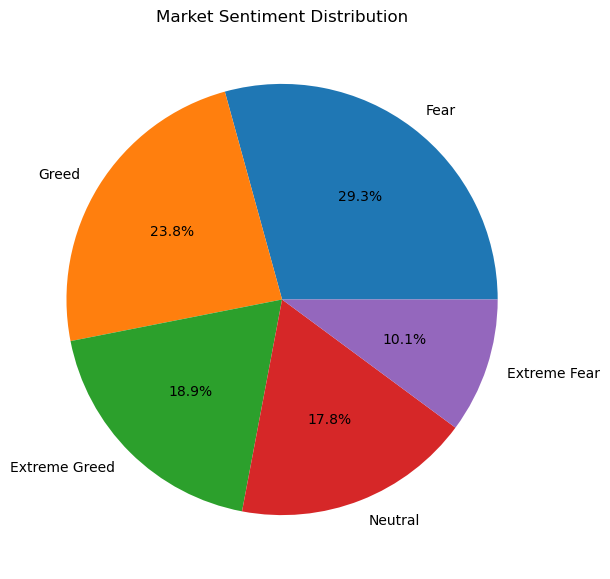

In [39]:
merged["classification"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(7,7)
)

plt.title("Market Sentiment Distribution")
plt.ylabel("")
plt.show()

## 9. Market Sentiment Distribution

### Insight

Fear accounts for the largest share of the dataset, followed by Greed. Extreme Fear represents the smallest portion. This shows that most trading activity occurred during normal Fear and Greed market conditions.

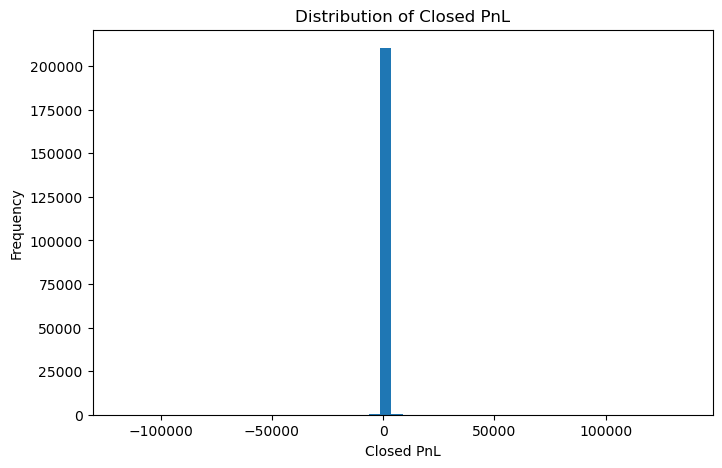

In [40]:
plt.figure(figsize=(8,5))

plt.hist(merged["Closed PnL"], bins=50)

plt.title("Distribution of Closed PnL")
plt.xlabel("Closed PnL")
plt.ylabel("Frequency")
plt.show()

## 10. Distribution of Closed PnL

### Insight

The histogram shows that most trades resulted in profits or losses close to zero, while only a few trades generated extremely large gains or losses. This indicates that the majority of trading outcomes were relatively moderate.

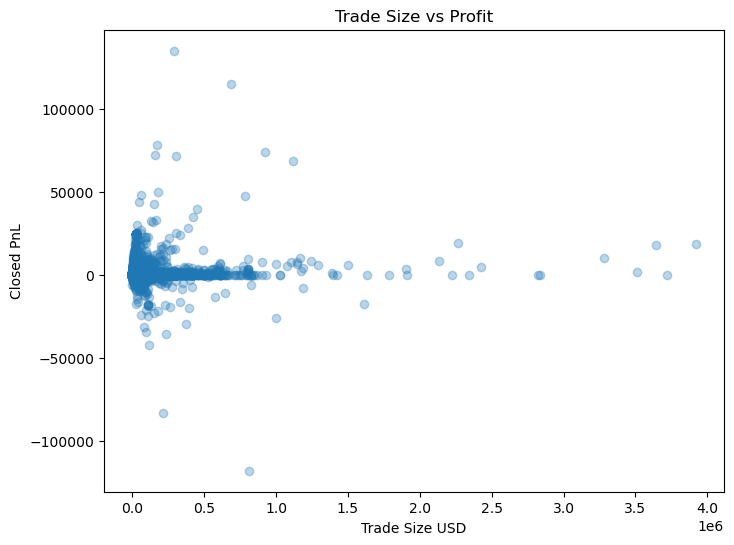

In [41]:
plt.figure(figsize=(8,6))

plt.scatter(
    merged["Size USD"],
    merged["Closed PnL"],
    alpha=0.3
)

plt.xlabel("Trade Size USD")
plt.ylabel("Closed PnL")
plt.title("Trade Size vs Profit")
plt.show()

## 11. Trade Size vs Profit

### Insight

The scatter plot suggests that there is no strong relationship between trade size and profit. Large trades do not always produce higher profits, and both small and large trades can result in gains or losses. This indicates that profitability depends more on market conditions and trading decisions than on trade size alone.

## Overall Observation

### Conclusion

The analysis reveals that market sentiment has a noticeable impact on trading performance. Extreme Greed shows the highest average profit and win rate, indicating better trading outcomes during highly optimistic market conditions. Most trades were executed during Fear and Greed phases, while profits were largely concentrated in a few coins. Overall, profitability appears to be influenced more by market sentiment and strategy rather than simply by trade size.